## Imports

In [15]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
from mypackages.eRDF import *
from tqdm import tqdm 
from mypackages.edp_processing import peak_calibration

from matplotlib import rcParams, cycler
from matplotlib.ticker import AutoMinorLocator

from mypackages.plot_style import set_plot_style

set_plot_style()

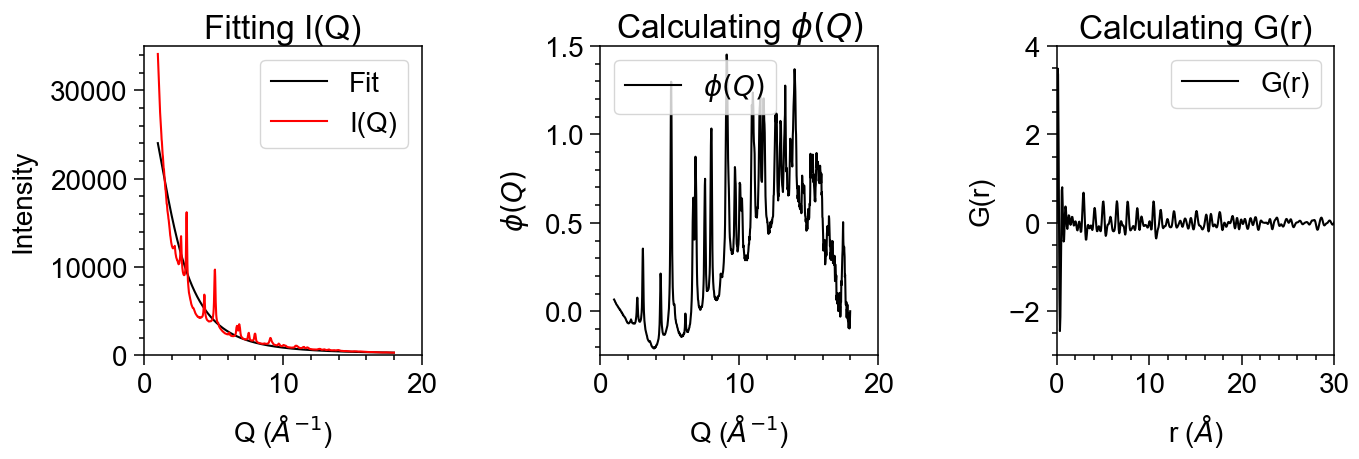

The q max is:17.98 and the qmin:0.98 


In [243]:
start_name = r"Z:\ActualWork\Victor\processed_data\b2_1s_250.csv"

df1 = pd.read_csv(start_name, header=None)

ds = (df1[0].values[0])/(2*math.pi) #AuNPs

df1 = pd.read_csv(start_name, header = None, skiprows=1, )

start = 2
data = df1.sum(axis=1)[start:]

CdSe =  {1: [30, 1], 2: [8, 1],}
Magnetite = {'Fe': [48, 2], 'O': [8, 3],}
Au = {'Au': [79, 1],}

qmin = 1
qmax = 18
start = int(qmin / (ds * 2 * math.pi))
end = int(qmax / (ds * 2 * math.pi))

end = min(end, data.shape[-1])

dp1 = DataProcessor(data = data, q0=0, lobato_path= None, start= start, end = end, ds = ds, Elements = Au, region = 0)
 

sq, fq = dp1.SQ_PhiQ(dp1.iq, damping=0)
r, Gr = dp1.Gr(fq, rmax=80, dr=0.05)


dp1.plot_results(fq, r, Gr0=Gr)

qmax_out = float(dp1.q.max())
qmin_out = float(dp1.q.min())
print(f"The q max is:{qmax_out:.2f} and the qmin:{qmin_out:.2f} ")


## Polynomial fitting

In [244]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt



# Normalize the data
norm_data = data[start:end] / (dp1.N * dp1.fq_sq)
norm_data = norm_data * dp1.q

degree = 8
# Fit the polynomial
coefficients = np.polyfit(dp1.q, norm_data, degree)
polynomial = np.poly1d(coefficients)

# Generate x values for plotting the polynomial fit
x_fit = np.linspace(dp1.q.min(), dp1.q.max(), len(norm_data))
y_fit = polynomial(x_fit)

# Calculate _fq_poly and apply Butterworth lowpass filter
fq_poly = norm_data - y_fit


In [242]:
qb1, fqb1 = dp1.q, fq_poly

## G(r) calculation

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mypackages.eRDF import Gr, read_discus_fit_file


# Calculate G(r) from F(Q)
r_raw, Gr_raw = Gr(dp1.q, fq_poly, rmax=100, dr=0.01)

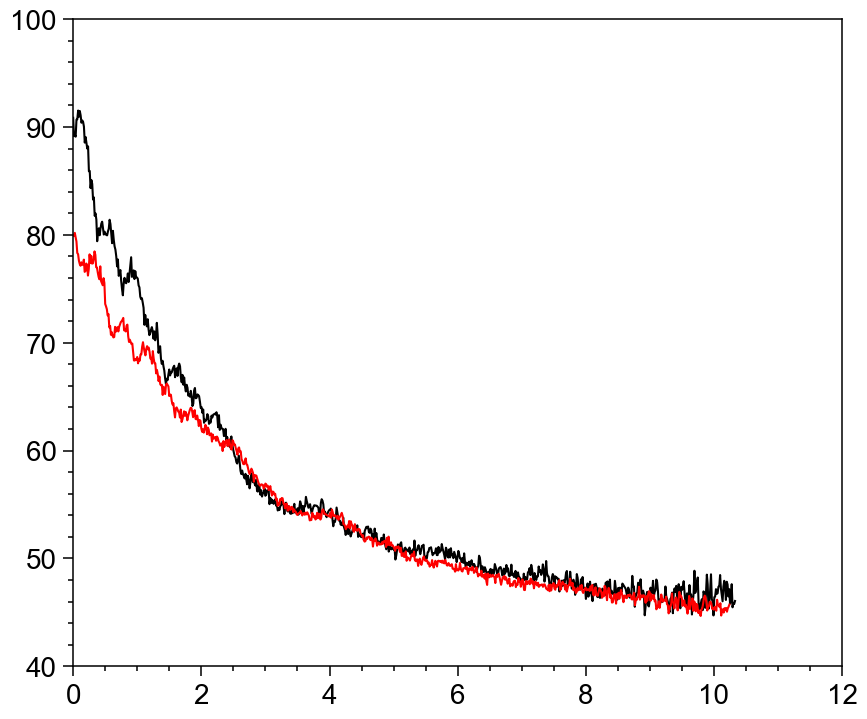

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

p = r"C:\Users\seccolev\data_processing\data\processed\ePDF\In2O3\20250822\in2o3_exp10s_spot6_f30.csv"
q = r"C:\Users\seccolev\data_processing\data\processed\ePDF\In2O3\20250815\in2o3_exp1s_spot2_f30.csv"

f30 =    pd.read_csv(p, header=None, skiprows = 1)
spirit = pd.read_csv(q, header=None, skiprows = 1)

iqf30 = f30[1].values[600:1400]
iqspirit = spirit[0].values[600:1400]

x = np.arange(0, len(iqf30)*0.012926118827172666,  0.012926118827172666)
x2 = np.arange(0, len(iqf30)*0.012816757013383256,  0.012816757013383256)

plt.plot(x, iqf30)
plt.plot(x2, iqspirit)

# plt.xlim(0,1400)
plt.show()


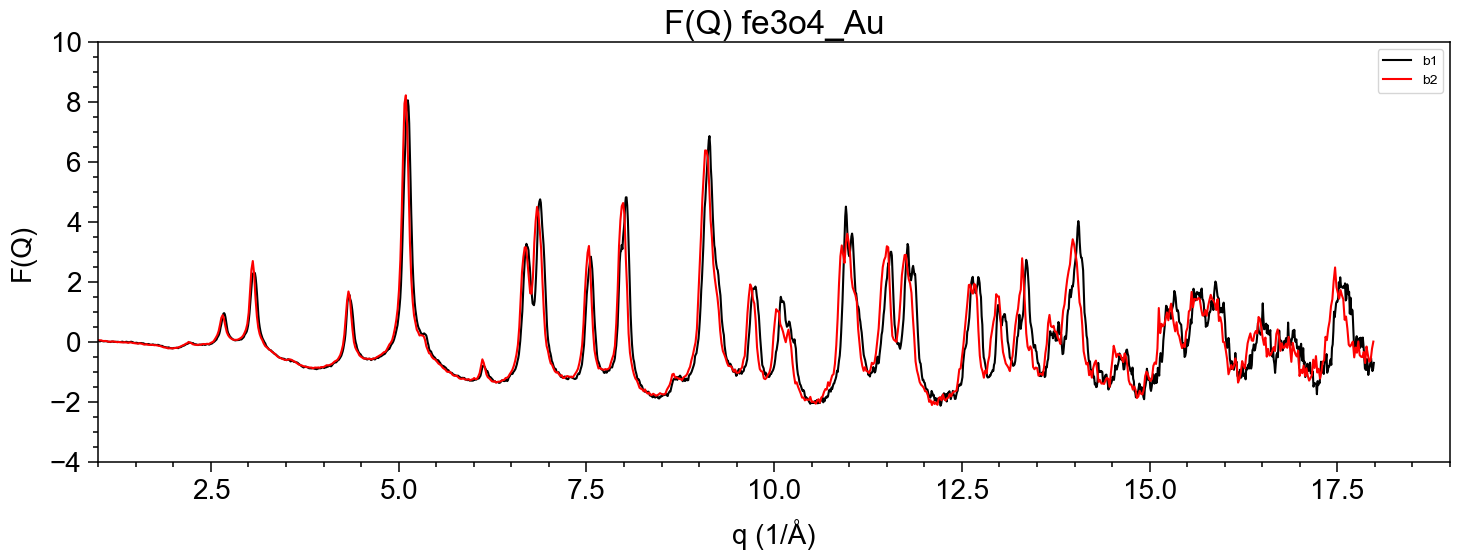

In [245]:
# Plot
plt.figure(figsize=(15, 6))

# F(Q)
plt.plot(qb1, fqb1, label='b1')
plt.plot(dp1.q, fq_poly, label='b2')
plt.xlim(1, 19)
plt.xlabel('q (1/Å)')
plt.ylabel('F(Q)')
plt.title('F(Q) fe3o4_Au')
plt.legend(fontsize=10)

# G(r)
# axs[1].plot(r_raw, Gr_raw, label='G(r) from F(Q)')
# axs[1].set_xlim(0, 60)
# axs[1].set_xlabel('r (Å)')
# axs[1].set_ylabel('G(r)')
# axs[1].set_title('G(r) fe3o4_2nm')
# axs[1].legend(fontsize=10)


plt.tight_layout()
plt.show()

# output_path = os.path.dirname(start_name)
# pd.DataFrame(np.array([dp1.q, fq_poly]).T, columns = ["q", "fq"]).to_csv(os.path.join(output_path, "fq_fe3o4_exp1s_spot4_spirit.csv"), sep="\t", index=None, )

In [ ]:
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline

def G_int_callable(G, upper=np.inf, limit=500, epsabs=1e-10, epsrel=1e-8):
    val, err = quad(lambda r: r * G(r), 0.0, upper, limit=limit, epsabs=epsabs, epsrel=epsrel)
    return val, err

def G_int_arrays(r, G, method="auto"):
    r = np.asarray(r, dtype=float)
    G = np.asarray(G, dtype=float)
    y = r * G
    if method == "auto":
        if (len(r) % 2 == 1) and np.allclose(np.diff(np.diff(r)), 0):
            return simpson(y, x=r, even="last")
        return np.trapz(y, r)
    if method == "simpson":
        return simpson(y, x=r, even="last")
    if method == "trapz":
        return np.trapz(y, r)
    raise ValueError("method must be 'auto', 'simpson', or 'trapz'")

def G_int_from_sampled_callable(r, G, k=3):
    spl = InterpolatedUnivariateSpline(r, G, k=k, ext=1)
    return quad(lambda x: x * spl(x), 0.0, r[-1])[0]


In [ ]:
import numpy as np

def integrate_rG(r, G, rmin=None, rmax=None, method="trapz"):
    r = np.asarray(r, float)
    G = np.asarray(G, float)
    m = np.isfinite(r) & np.isfinite(G)
    if rmin is not None:
        m &= r >= rmin
    if rmax is not None:
        m &= r <= rmax
    r = r[m]
    y = r * G[m]
    if method == "trapz":
        return np.trapz(y, r)
    elif method == "simpson":
        from scipy.integrate import simpson
        return simpson(y, x=r, even="last")
    else:
        raise ValueError("method must be 'trapz' or 'simpson'")

G_int_total = integrate_rG(r_raw, Gr_raw*5)
r_cut = 100.0
G_int_0_R = integrate_rG(r_raw, Gr_raw, rmax=r_cut)

print("G_int total:", G_int_total)
print(f"G_int [0, {r_cut}]:", G_int_0_R)


G_int total: -0.9724988608333401
G_int [0, 100.0]: -0.12071248880410196


C:\Users\seccolev\AppData\Local\Temp\ipykernel_22376\2522659068.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, r)


## G(r) Lorch calculation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mypackages.eRDF import Gr, calc_Gr_Lorch

# Parameters
rmax = 200
dr = 0.05

# Compute G(r) with and without Lorch window
r_lorch, Gr_lorch = calc_Gr_Lorch(q, fq, rmax=rmax, dr=dr, rmin=0, transition_width=5)
r_raw, Gr_raw = Gr(q, fq, rmax=rmax, dr=dr)

xmin = 0 
xmax = 2500

# Plot comparison
plt.figure(figsize=(16, 5))
plt.plot(r_raw[xmin:xmax], Gr_raw[xmin:xmax], label='G(r) raw', alpha=0.8)
plt.plot(r_lorch[xmin:xmax], Gr_lorch[xmin:xmax], label='G(r) with Lorch', alpha=0.9)
plt.xlabel('r (Å)')
plt.ylabel('G(r)')
plt.xlim(0,100)
plt.title('Comparison of G(r) with and without Lorch Window')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## EnvACS exporting

In [ ]:
import os

output_path = os.path.dirname(input_path_gr)

pd.DataFrame([r_raw,Gr_raw], index=None).T.to_csv(os.path.join(output_path, "Gr_CdSe_P5_EnvACS.csv"), index=None)
